# `funder` 01: basic `high-cardinality-category` breakdown

**Purpose:** apply the analysis that is always performed for this feature
type, without mixing in cross-feature interpretation.

**Current role:** `candidate`

**Provisional disposition:** retain after conservative normalisation and fold-fitted rare grouping


## Standard checks for `high-cardinality-category`

        Every predictor with this audit type receives the same basic checks:

        - source blanks and semantic sentinel tokens
- cardinality, singletons and rare-level row coverage
- normalisation effects and test-only levels
- memorisation risk and fold-fitted encoding options

        This notebook stays descriptive. Target interpretation belongs in notebook 02,
        and cross-feature relationships belong in notebook 03.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_stage_directory():
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (
            (candidate / "data" / "TrainingSetValues.csv").exists()
            and (candidate / "src" / "source_data_validation.py").exists()
        ):
            return candidate
    raise FileNotFoundError("Could not locate the stage-1-pump-it-up directory.")


stage_directory = find_stage_directory()
source_directory = str((stage_directory / "src").resolve())
if source_directory not in sys.path:
    sys.path.insert(0, source_directory)

from predictor_audit import (
    analysis_categories,
    categorical_summary,
    categorical_target_profile,
    category_frequency_table,
    numeric_summary,
    numeric_target_summary,
    related_feature_summary,
    sentinel_mask,
    source_blank_mask,
    text_normalisation_summary,
)
from source_data_validation import (
    validate_aligned_ids,
    validate_label_frame,
    validate_raw_feature_schema,
)

data_directory = stage_directory / "data"
training_features = pd.read_csv(
    data_directory / "TrainingSetValues.csv",
    keep_default_na=False,
)
training_labels = pd.read_csv(
    data_directory / "TrainingSetLabels.csv",
    keep_default_na=False,
)
test_features = pd.read_csv(
    data_directory / "TestSetValues.csv",
    keep_default_na=False,
)

validate_raw_feature_schema(training_features)
validate_raw_feature_schema(test_features)
validate_label_frame(training_labels)
validate_aligned_ids(training_features, training_labels)

training_data = training_features.merge(
    training_labels,
    on="id",
    validate="one_to_one",
)

feature = 'funder'
feature_metadata = {'order': 3, 'name': 'funder', 'audit_type': 'high-cardinality-category', 'role': 'candidate', 'disposition': 'retain after conservative normalisation and fold-fitted rare grouping', 'finding': 'Effective missingness is about 7.5% and a small but material test share uses unseen funders.', 'decision': 'Keep blank and sentinel states distinct, normalise conservatively and handle unseen levels explicitly.', 'risk': 'Naive target encoding leaks and unrestricted fuzzy merging can combine different organisations.', 'sentinel_tokens': ['0', 'None', 'unknown', 'not known'], 'related': [{'feature': 'installer', 'reason': 'Funding and installation organisations are strongly associated but not duplicates.'}, {'feature': 'scheme_name', 'reason': 'A funder may repeatedly support named schemes.'}, {'feature': 'region', 'reason': 'Organisation activity is geographically concentrated.'}]}
feature_types = {'amount_tsh': 'numeric', 'date_recorded': 'date', 'funder': 'high-cardinality-category', 'gps_height': 'numeric', 'installer': 'high-cardinality-category', 'longitude': 'coordinate', 'latitude': 'coordinate', 'wpt_name': 'high-cardinality-category', 'num_private': 'numeric', 'basin': 'category', 'subvillage': 'high-cardinality-category', 'region': 'category', 'region_code': 'category', 'district_code': 'category', 'lga': 'category', 'ward': 'high-cardinality-category', 'population': 'numeric', 'public_meeting': 'binary', 'recorded_by': 'constant', 'scheme_management': 'category', 'scheme_name': 'high-cardinality-category', 'permit': 'binary', 'construction_year': 'year', 'extraction_type': 'category', 'extraction_type_group': 'category', 'extraction_type_class': 'category', 'management': 'category', 'management_group': 'category', 'payment': 'category', 'payment_type': 'category', 'water_quality': 'category', 'quality_group': 'category', 'quantity': 'category', 'quantity_group': 'category', 'source': 'category', 'source_type': 'category', 'source_class': 'category', 'waterpoint_type': 'category', 'waterpoint_type_group': 'category'}
assert feature in training_features.columns
print(
    f"Validated {len(training_features):,} training rows and "
    f"{len(test_features):,} test rows for {feature}."
)


Validated 59,400 training rows and 14,850 test rows for funder.


## Missingness, cardinality and category coverage


In [2]:
sentinel_tokens = ['0', 'None', 'unknown', 'not known']
overview = categorical_summary(
    training_features,
    test_features,
    [feature],
    rare_threshold=50,
    sentinel_tokens_by_column={feature: sentinel_tokens},
)
display(overview)
display(
    category_frequency_table(
        training_features,
        test_features,
        feature,
        top_n=15,
        sentinel_tokens=sentinel_tokens,
    )
)


,training explicit missing,training source blank rows,training sentinel rows,test explicit missing,test source blank rows,test sentinel rows,training levels,test levels,training levels with <50 rows,training rows in rare levels (%),test-only levels,test rows in unseen levels (%),training-only levels,marginal total-variation distance
feature,,,,,,,,,,,,,,
funder,0,3635,810,0,869,210,1897,980,1753,14.89,243,1.71,1160,0.0823


,training rows,training (%),test rows,test (%)
funder,,,,
government of tanzania,9084,15.29,2215,14.92
<missing/blank>,3635,6.12,869,5.85
danida,3114,5.24,793,5.34
hesawa,2202,3.71,580,3.91
rwssp,1374,2.31,329,2.22
world bank,1349,2.27,352,2.37
kkkt,1287,2.17,336,2.26
world vision,1246,2.1,316,2.13
unicef,1057,1.78,267,1.8


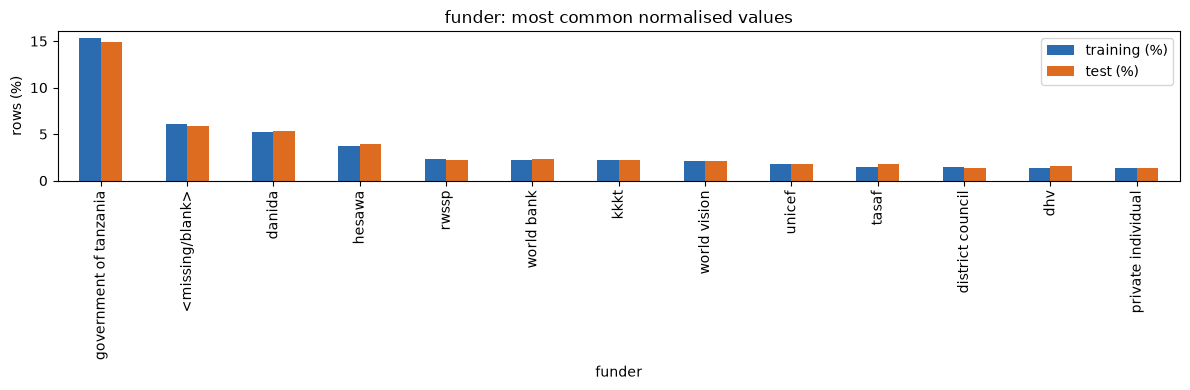

In [3]:
top = category_frequency_table(
    training_features,
    test_features,
    feature,
    top_n=12,
    sentinel_tokens=sentinel_tokens,
)[["training (%)", "test (%)"]]
top.plot(kind="bar", figsize=(12, 4), color=["#2b6cb0", "#dd6b20"])
plt.ylabel("rows (%)")
plt.title(f"{feature}: most common normalised values")
plt.tight_layout()
plt.show()


## Basic-breakdown handoff

The outputs above establish shape, missingness, support and supplied
train/test coverage. They do not by themselves establish usefulness or a
causal explanation. Notebook 02 interprets noteworthy single-feature
evidence; notebook 03 tests the explicitly related predictors.
